# 03 — Analysis: rent growth, affordability & bedroom premium

This notebook turns the SQL views built in `sql/` into the final headline metrics
and figures for the project. It reads three views from the `ireland_rental`
PostgreSQL database:

- `v_rent_growth` — first vs latest published rent per county
- `v_affordability` — annual rent as a share of regional median earnings
- `v_bedroom_premium` — average rent by bedroom size, nationally, latest year

Connection settings come from the standard `PG*` environment variables so no
credentials live in the repo. Figures are written to `../figures/` for the README.

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")

FIGURES = Path("..") / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

BLUE, RED = "#4c72b0", "#c44e52"


def get_engine():
    password = os.environ.get("PGPASSWORD")
    if not password:
        raise RuntimeError(
            "PGPASSWORD is not set. Set it in the environment before running."
        )
    url = URL.create(
        "postgresql+psycopg2",
        username=os.environ.get("PGUSER", "postgres"),
        password=password,
        host=os.environ.get("PGHOST", "localhost"),
        port=int(os.environ.get("PGPORT", "5432")),
        database=os.environ.get("PGDATABASE", "ireland_rental"),
    )
    return create_engine(url)


engine = get_engine()

## Load the SQL views

In [2]:
growth = pd.read_sql("SELECT * FROM v_rent_growth", engine)
afford = pd.read_sql("SELECT * FROM v_affordability", engine)
premium = pd.read_sql("SELECT * FROM v_bedroom_premium", engine)

print("v_rent_growth    ", growth.shape)
print("v_affordability  ", afford.shape)
print("v_bedroom_premium", premium.shape)

v_rent_growth     (26, 8)
v_affordability   (26, 8)
v_bedroom_premium (4, 5)


## 1. Where has rent grown fastest?

Each county is compared on the headline *All bedrooms / All property types* series,
using that county's own earliest and latest published quarter (not every county
has a 2014Q1 reading). Growth is the percentage change between those two points.

In [3]:
national_growth = {
    "counties": len(growth),
    "median_pct_change": round(growth["pct_change"].median(), 1),
    "mean_pct_change": round(growth["pct_change"].mean(), 1),
}
national_growth

{'counties': 26,
 'median_pct_change': np.float64(123.7),
 'mean_pct_change': np.float64(126.3)}

In [4]:
cols = ["county", "first_quarter", "first_rent",
        "last_quarter", "last_rent", "pct_change"]
print("Fastest-growing:")
display(growth.nlargest(3, "pct_change")[cols])
print("Slowest-growing:")
display(growth.nsmallest(3, "pct_change")[cols])

Fastest-growing:


,county,first_quarter,first_rent,last_quarter,last_rent,pct_change
0,Longford,2014Q1,400.5,2025Q3,"1,140.2",184.7
1,Limerick,2014Q1,614.0,2025Q3,"1,658.0",170.0
2,Cavan,2014Q1,441.9,2025Q3,"1,102.7",149.5


Slowest-growing:


,county,first_quarter,first_rent,last_quarter,last_rent,pct_change
25,Dublin,2014Q1,"1,104.8",2025Q3,"2,173.5",96.7
24,Tipperary,2014Q1,542.3,2025Q3,"1,094.4",101.8
23,Kilkenny,2014Q1,602.9,2025Q3,"1,229.4",103.9


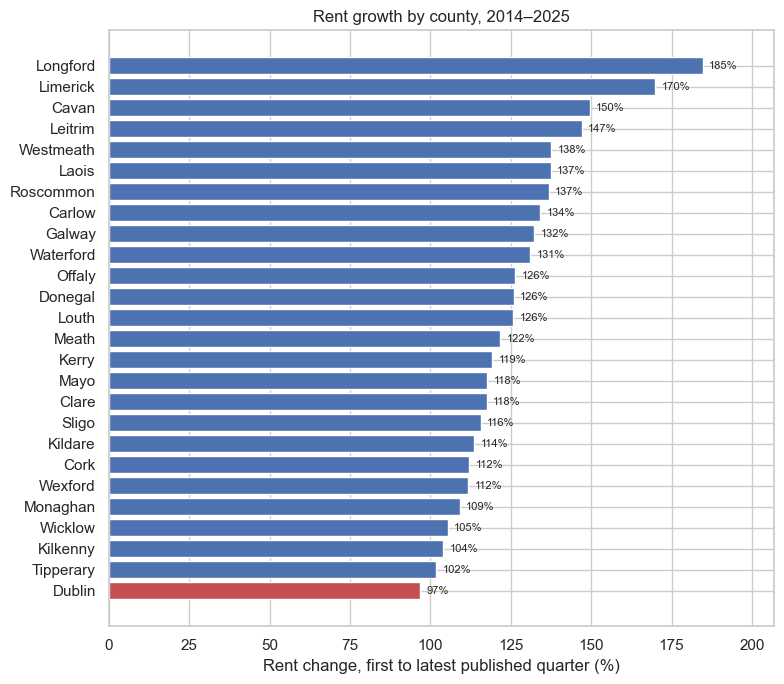

In [5]:
order = growth.sort_values("pct_change")
colors = [RED if c == "Dublin" else BLUE for c in order["county"]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(order["county"], order["pct_change"], color=colors)
ax.set_xlabel("Rent change, first to latest published quarter (%)")
ax.set_title("Rent growth by county, 2014–2025")
for y, v in enumerate(order["pct_change"]):
    ax.text(v + 2, y, f"{v:.0f}%", va="center", fontsize=8)
ax.margins(x=0.12)
fig.tight_layout()
fig.savefig(FIGURES / "rent_growth_by_county.png", dpi=150)
plt.show()

Rent has risen fastest in smaller inland counties coming off low 2014 bases —
Longford, Limerick and Cavan lead. Dublin shows the *smallest* percentage rise,
but from by far the highest starting rent, so the euro gap is still the widest.

## 2. Where is rent least affordable vs local wages?

Affordability is annual rent (latest year, x12) divided by the **regional median
earnings** for the county's NUTS 3 region. Earnings only exist to 2024, so 2025
rents are compared against 2024 earnings.

In [6]:
acols = ["county", "region", "avg_monthly_rent",
         "annual_rent", "median_earnings", "rent_pct_of_income"]
print("Most burdened:")
display(afford.nlargest(3, "rent_pct_of_income")[acols])
print("Least burdened:")
display(afford.nsmallest(3, "rent_pct_of_income")[acols])
print("National median share of income: "
      f"{afford['rent_pct_of_income'].median():.1f}%")

Most burdened:


,county,region,avg_monthly_rent,annual_rent,median_earnings,rent_pct_of_income
0,Dublin,Dublin,"2,146.0","25,752.0","49,224.0",52.3
1,Galway,West,"1,605.0","19,260.0","42,795.0",45.0
2,Wicklow,Mid-East,"1,724.0","20,688.0","46,088.0",44.9


Least burdened:


,county,region,avg_monthly_rent,annual_rent,median_earnings,rent_pct_of_income
25,Tipperary,Mid-West,"1,070.0","12,840.0","43,269.0",29.7
24,Donegal,Border,974.0,"11,688.0","39,197.0",29.8
23,Leitrim,Border,981.0,"11,772.0","39,197.0",30.0


National median share of income: 34.8%


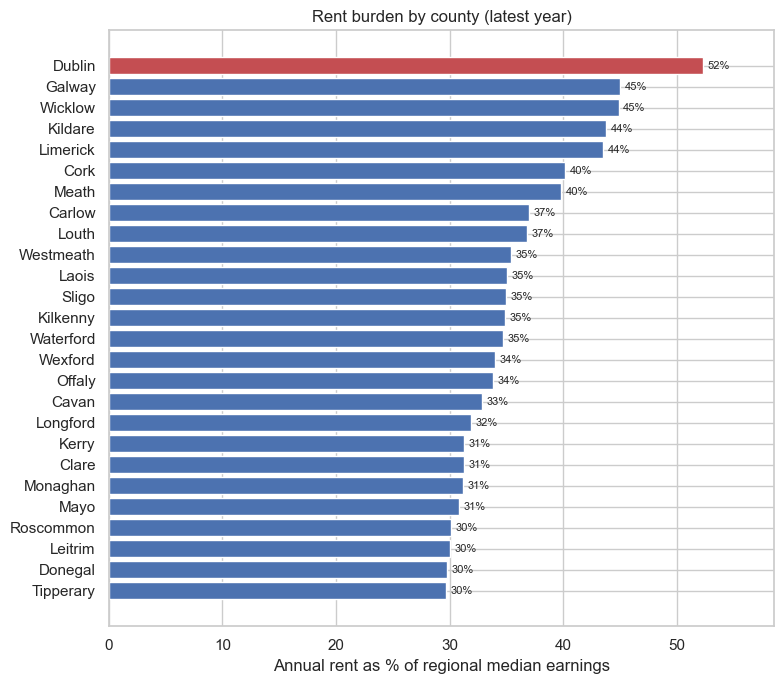

In [7]:
order = afford.sort_values("rent_pct_of_income")
colors = [RED if c == "Dublin" else BLUE for c in order["county"]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(order["county"], order["rent_pct_of_income"], color=colors)
ax.set_xlabel("Annual rent as % of regional median earnings")
ax.set_title("Rent burden by county (latest year)")
for y, v in enumerate(order["rent_pct_of_income"]):
    ax.text(v + 0.4, y, f"{v:.0f}%", va="center", fontsize=8)
ax.margins(x=0.12)
fig.tight_layout()
fig.savefig(FIGURES / "affordability_by_county.png", dpi=150)
plt.show()

Dublin renters spend the largest share of local wages on rent, followed by
Galway and Wicklow. Because earnings are only available at region level, counties
within the same region are separated purely by their rents.

## 3. What does an extra bedroom cost?

National average rent by bedroom size in the latest year, with the euro step-up
and percentage uplift from the next-smaller size.

In [8]:
display(premium[["bedrooms", "avg_rent", "extra_vs_smaller", "pct_uplift"]])

,bedrooms,avg_rent,extra_vs_smaller,pct_uplift
0,One bed,958.0,NaN,NaN
1,Two bed,"1,208.0",250.0,26.1
2,Three bed,"1,349.0",141.0,11.7
3,Four plus bed,"1,626.0",277.0,20.5


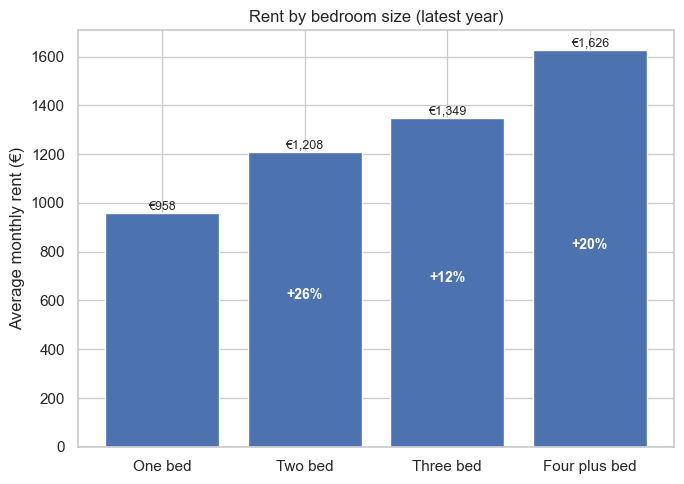

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(premium["bedrooms"], premium["avg_rent"], color=BLUE)
ax.set_ylabel("Average monthly rent (€)")
ax.set_title("Rent by bedroom size (latest year)")
for i, row in premium.iterrows():
    ax.text(i, row["avg_rent"] + 15, f"€{row['avg_rent']:,.0f}",
            ha="center", fontsize=9)
    if pd.notna(row["pct_uplift"]):
        ax.text(i, row["avg_rent"] / 2, f"+{row['pct_uplift']:.0f}%",
                ha="center", color="white", fontsize=10, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES / "bedroom_premium.png", dpi=150)
plt.show()

The first extra bedroom is the most expensive jump (one-bed to two-bed, +26%).
Adding a third bedroom is the cheapest step in percentage terms, and the fourth-plus
size steps up again.

## Key metrics summary

In [10]:
fastest = growth.nlargest(1, "pct_change").iloc[0]
dublin_g = growth.loc[growth["county"] == "Dublin"].iloc[0]
most_burdened = afford.nlargest(1, "rent_pct_of_income").iloc[0]
least_burdened = afford.nsmallest(1, "rent_pct_of_income").iloc[0]

summary = pd.DataFrame(
    [
        ["Fastest rent growth",
         f"{fastest['county']} +{fastest['pct_change']:.1f}% "
         f"(€{fastest['first_rent']:,.0f} → €{fastest['last_rent']:,.0f})"],
        ["Slowest rent growth",
         f"{dublin_g['county']} +{dublin_g['pct_change']:.1f}% "
         f"(€{dublin_g['first_rent']:,.0f} → €{dublin_g['last_rent']:,.0f})"],
        ["Most rent-burdened",
         f"{most_burdened['county']} {most_burdened['rent_pct_of_income']:.1f}% of income"],
        ["Least rent-burdened",
         f"{least_burdened['county']} {least_burdened['rent_pct_of_income']:.1f}% of income"],
        ["Costliest bedroom step",
         f"one-bed → two-bed +{premium['pct_uplift'].max():.0f}%"],
    ],
    columns=["metric", "headline"],
)
summary

,metric,headline
0,Fastest rent growth,"Longford +184.7% (€400 → €1,140)"
1,Slowest rent growth,"Dublin +96.7% (€1,105 → €2,173)"
2,Most rent-burdened,Dublin 52.3% of income
3,Least rent-burdened,Tipperary 29.7% of income
4,Costliest bedroom step,one-bed → two-bed +26%
